# Test Model Notebook
Bu dosya eğitilen modelleri yükler ve test seti üzerinde değerlendirme yapar.
# Overfitting ile ilgili referans: https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf


In [2]:
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack

In [3]:
# Veri seti yükleme ve temizleme
df = pd.read_csv("data/fake_reviews_dataset.csv")
df.rename(columns={"text_": "review"}, inplace=True)
df["review"] = df["review"].astype(str)

df['label'] = df['label'].map({'CG': 0, 'OR': 1})
df = df.rename(columns={'text_': 'review'})
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text
df['clean_review'] = df['review'].apply(clean_text)
df['review_length'] = df['review'].apply(lambda x: len(str(x)))
df['exclamation_count'] = df['review'].apply(lambda x: str(x).count('!'))
df['capital_word_ratio'] = df['review'].apply(lambda x: len([w for w in str(x).split() if w.isupper()]) / (len(str(x).split()) + 1e-5))

In [4]:

# TF-IDF vektörleştiriciyi yükle
tfidf = joblib.load('models/tfidf_vectorizer_demo.pkl')

# TF-IDF transform (fit yapılmaz!)
X_tfidf = tfidf.transform(df['clean_review'])


In [5]:

# Eğitimde kaydedilen test verilerini yükle
X_test = joblib.load('models/X_test_combined_demo.pkl')
y_test = joblib.load('models/y_test_labels_demo.pkl')


In [6]:

# Eğitimde kaydedilen LSTM test verilerini yükle
X_test_lstm = joblib.load("models/X_test_lstm_demo.pkl")
y_test_lstm = joblib.load("models/y_test_lstm_demo.pkl")


In [7]:

# Tokenizer ve test verisini yükle
tokenizer = joblib.load("models/lstm_tokenizer_dataset1_demo.pkl")
X_test_lstm = joblib.load("models/X_test_lstm_demo.pkl")
y_test_lstm = joblib.load("models/y_test_lstm_demo.pkl")



In [8]:
from keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Modeli yükle
model = load_model("models/lstm_model_dataset1_demo.h5")

# Tahmin al
preds = model.predict(X_test_lstm)
preds_binary = (preds >= 0.5).astype(int)

# Skorları hesapla
acc = accuracy_score(y_test_lstm, preds_binary)
precision = precision_score(y_test_lstm, preds_binary)
recall = recall_score(y_test_lstm, preds_binary)
f1 = f1_score(y_test_lstm, preds_binary)

# Sonuçları yazdır
print("LSTM MODEL TEST SONUÇLARI\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_lstm, preds_binary))
print("\nClassification Report:")
print(classification_report(y_test_lstm, preds_binary, digits=4))
print(f"Accuracy Score: {acc:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")





1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step
LSTM MODEL TEST SONUÇLARI

Confusion Matrix:
[[2 0]
 [2 0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5000    1.0000    0.6667         2
           1     0.0000    0.0000    0.0000         2

    accuracy                         0.5000         4
   macro avg     0.2500    0.5000    0.3333         4
weighted avg     0.2500    0.5000    0.3333         4

Accuracy Score: 0.5000
Precision Score: 0.0000
Recall Score: 0.0000
F1 Score: 0.0000


C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\

C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

ROC-AUC: 0.5


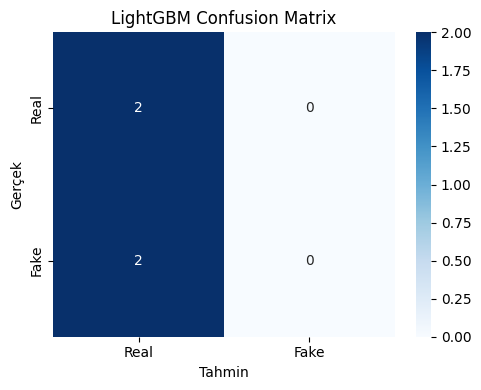

In [9]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Modeli yükle
lgb_model = joblib.load("models/lightgbm_model_demo.pkl")
y_pred_lgb = lgb_model.predict(X_test.toarray())
y_prob_lgb = lgb_model.predict_proba(X_test.toarray())[:, 1]

print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))

# Confusion Matrix
conf = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(5, 4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.savefig("plots/lightgbm_confusion_matrix_2nd_dataset.png")


In [10]:
# [Yorumlandı - yanlış kullanım]
# # Özellik çıkarımı ve veri ayırma
# tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
# X_tfidf = tfidf.fit_transform(df['clean_review'])
# X_numeric = df[['review_length', 'exclamation_count', 'capital_word_ratio']].values
# X_combined = hstack([X_tfidf, X_numeric])
# y = df['label'].values
# X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Modeli yükle ve test et
nb_model = joblib.load('models/naive_bayes_model_demo.pkl')
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



In [12]:
import joblib
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# Model dosyalarının yolu (klasör adı farklıysa değiştir)
model_dir = "models/"

# Tüm modelleri yükle
naive_bayes = joblib.load(model_dir + "naive_bayes_model_demo.pkl")
svm = joblib.load(model_dir + "svm_model_demo.pkl")
lgbm = joblib.load(model_dir + "lightgbm_model_demo.pkl")
mlp = joblib.load(model_dir + "mlp_model_demo.pkl")
tfidf = joblib.load(model_dir + "tfidf_vectorizer_demo.pkl")
X_test = joblib.load(model_dir + "X_test_combined_demo.pkl")
y_test = joblib.load(model_dir + "y_test_labels_demo.pkl")

# Modelleri test et ve sonuçları yazdır
models = {
    "Naive Bayes": naive_bayes,
    "SVM": svm,
    "LightGBM": lgbm,
    "MLP": mlp
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"==== {name} ====")
    print(classification_report(y_test, y_pred, digits=4))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")


==== Naive Bayes ====
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         2
           1     0.3333    0.5000    0.4000         2

    accuracy                         0.2500         4
   macro avg     0.1667    0.2500    0.2000         4
weighted avg     0.1667    0.2500    0.2000         4

Accuracy: 0.25
F1 Score: 0.4
Confusion Matrix:
 [[0 2]
 [1 1]]


==== SVM ====
              precision    recall  f1-score   support

           0     0.5000    1.0000    0.6667         2
           1     0.0000    0.0000    0.0000         2

    accuracy                         0.5000         4
   macro avg     0.2500    0.5000    0.3333         4
weighted avg     0.2500    0.5000    0.3333         4

Accuracy: 0.5
F1 Score: 0.0
Confusion Matrix:
 [[2 0]
 [2 0]]


==== LightGBM ====
              precision    recall  f1-score   support

           0     0.5000    1.0000    0.6667         2
           1     0.0000    0.0000    0.0000         2

C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kayra\anaconda3\envs\tfenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape